# Comparison of CollecTRI TF activities across contrasts

Compares the TF activities inferred with `decoupler.mt.ulm` + CollecTRI in each CORNETO notebook (AXL, ERBB2 sham/MI, hOSM, mOSM, mLIF, IGF1).

Heatmaps:
1. All TFs significant (padj < threshold) in at least one contrast.
2. IFN-related TFs.
3. Cell cycle-related TFs.

Colour = ULM activity score (red = more active in the perturbation, blue = less active). A star marks cells where the TF is significant in that contrast. Grey = TF not tested in that contrast (e.g. not enough targets after ortholog mapping).

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

In [2]:
root_dir = '/mnt/sds-hd/sd22b002/projects/ines/axl_networks'
figures_dir = f'{root_dir}/figures/collectri_comparison'
results_dir = f'{root_dir}/results/collectri_comparison'
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

padj_threshold = 0.05

collectri_files = {
    'AXL vs GFP': f'{root_dir}/results/axl_vs_gfp_collectri_results.csv',
    'ERBB2 OE vs WT (sham)': f'{root_dir}/results/erbb2/corneto/erbb2_wt-vs-oe_sham_collectri_results.csv',
    'ERBB2 OE vs WT (MI)': f'{root_dir}/results/erbb2/corneto/erbb2_wt-vs-oe_mi_collectri_results.csv',
    'hOSM vs Control': f'{root_dir}/results/osm_lif/corneto/hOSM_vs_Control_collectri_results.csv',
    'mOSM vs Control': f'{root_dir}/results/osm_lif/corneto/mOSM_vs_Control_collectri_results.csv',
    'mLIF vs Control': f'{root_dir}/results/osm_lif/corneto/mLIF_vs_Control_collectri_results.csv',
    'IGF1 vs Control': f'{root_dir}/results/igf1/corneto/IGF1_vs_Control_collectri_results.csv',
}

## Load CollecTRI results
Each file has columns `TF`, `activity`, `padj`. We build two wide tables (TF x contrast): activity scores and adjusted p-values.

In [3]:
activities, padjs = {}, {}
for contrast, path in collectri_files.items():
    df = pd.read_csv(path).set_index('TF')
    activities[contrast] = df['activity']
    padjs[contrast] = df['padj']

activity_df = pd.DataFrame(activities)
padj_df = pd.DataFrame(padjs)
sig_df = padj_df < padj_threshold  # NaN (TF not tested) -> False

activity_df.to_csv(f'{results_dir}/collectri_activity_all_contrasts.csv')
padj_df.to_csv(f'{results_dir}/collectri_padj_all_contrasts.csv')

print(activity_df.shape)
sig_df.sum().rename('n_significant_TFs')

(719, 7)


AXL vs GFP               81
ERBB2 OE vs WT (sham)    59
ERBB2 OE vs WT (MI)      29
hOSM vs Control          29
mOSM vs Control          37
mLIF vs Control           7
IGF1 vs Control          35
Name: n_significant_TFs, dtype: int64

## Heatmap function

In [4]:
def plot_tf_heatmap(tfs, title, fname, cluster_rows=True, row_height=0.35, col_width=0.5,
                    ytick_fontsize=9, star_size=60):
    """Heatmap of CollecTRI activities (TF x contrast) with a star on significant cells."""
    missing = [tf for tf in tfs if tf not in activity_df.index]
    if missing:
        print(f'Not found in any CollecTRI result, skipped: {missing}')
    tfs = [tf for tf in tfs if tf in activity_df.index]

    mat = activity_df.loc[tfs]
    sig = sig_df.loc[tfs]

    # Hierarchical clustering of rows (untested values set to 0 only for the clustering)
    if cluster_rows and len(tfs) > 2:
        order = leaves_list(linkage(mat.fillna(0).values, method='average', metric='euclidean'))
        mat, sig = mat.iloc[order], sig.iloc[order]

    n_rows, n_cols = mat.shape
    vmax = np.nanmax(np.abs(mat.values))
    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad('lightgrey')

    fig, ax = plt.subplots(figsize=(col_width * n_cols, 1.5 + row_height * n_rows))
    im = ax.imshow(np.ma.masked_invalid(mat.values), cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')

    # Stars on significant cells; white on dark cells, black on light ones
    rows, cols = np.where(sig.values)
    star_colors = ['white' if abs(mat.iat[i, j]) > 0.6 * vmax else 'black' for i, j in zip(rows, cols)]
    ax.scatter(cols, rows, marker='*', s=star_size, c=star_colors, linewidths=0)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(mat.columns, rotation=90, ha='center')
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(mat.index, fontsize=ytick_fontsize)
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.5)
    ax.tick_params(which='minor', length=0)
    ax.set_title(f'{title}\n(\u2605 padj < {padj_threshold}; grey = not tested)', fontsize=11)

    cbar = fig.colorbar(im, ax=ax, shrink=min(1.0, 6 / n_rows + 0.3), pad=0.02)
    cbar.set_label('CollecTRI activity (ULM score)')

    fig.tight_layout()
    fig.savefig(f'{figures_dir}/{fname}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{figures_dir}/{fname}.pdf', bbox_inches='tight')
    plt.show()
    return mat

## All TFs significant in at least one contrast

165 TFs significant in at least one contrast


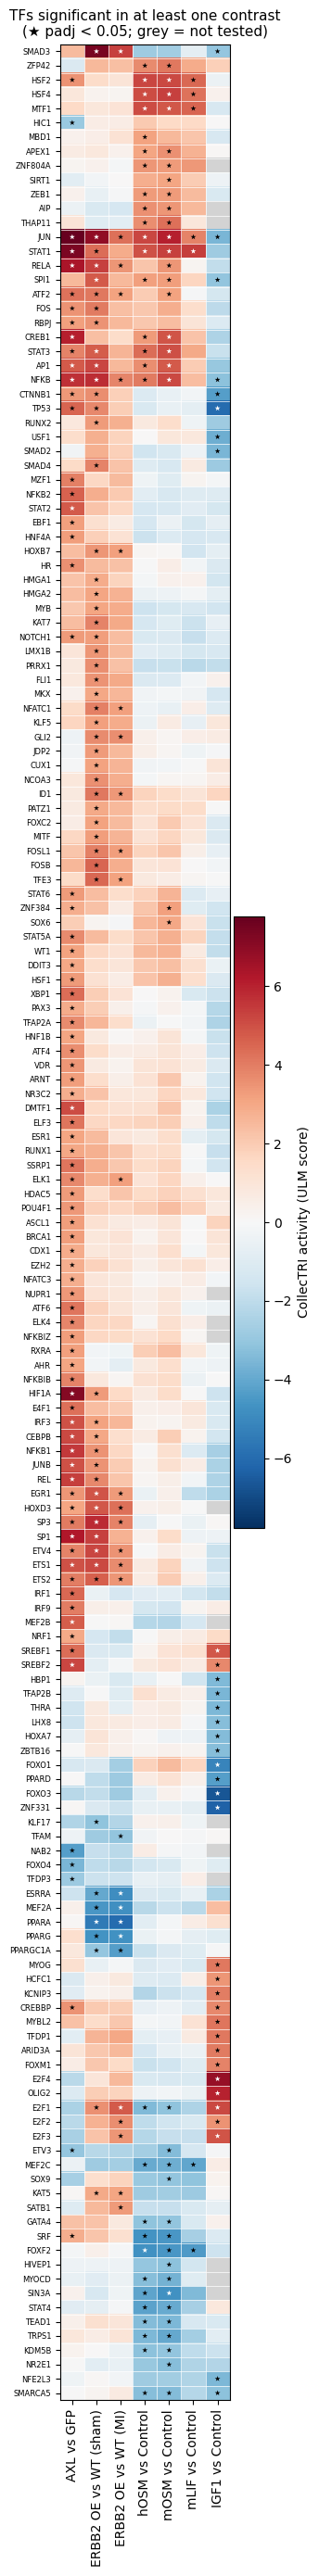

In [5]:
sig_any_tfs = sig_df.index[sig_df.any(axis=1)].tolist()
print(f'{len(sig_any_tfs)} TFs significant in at least one contrast')

all_sig_mat = plot_tf_heatmap(
    sig_any_tfs,
    title='TFs significant in at least one contrast',
    fname='collectri_heatmap_all_significant_tfs',
    row_height=0.16, ytick_fontsize=6, star_size=20,
)

## IFN-related TFs
ISGF3 components (STAT1, STAT2, IRF9) plus the IRF family. Edit the list to add/remove TFs.

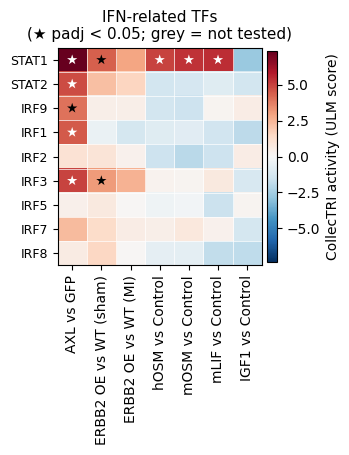

In [6]:
ifn_tfs = ['STAT1', 'STAT2', 'IRF9', 'IRF1', 'IRF2', 'IRF3', 'IRF5', 'IRF7', 'IRF8']

ifn_mat = plot_tf_heatmap(
    ifn_tfs,
    title='IFN-related TFs',
    fname='collectri_heatmap_ifn_tfs',
    cluster_rows=False,
)

## Cell cycle-related TFs
E2F/DP family, G2/M drivers (FOXM1, MYBL2), MYC, and the RB1/TP53 brakes. Edit the list to add/remove TFs.

Not found in any CollecTRI result, skipped: ['E2F8']


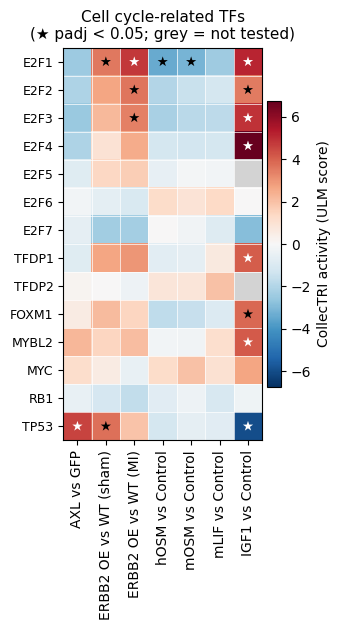

In [7]:
cell_cycle_tfs = ['E2F1', 'E2F2', 'E2F3', 'E2F4', 'E2F5', 'E2F6', 'E2F7', 'E2F8',
                  'TFDP1', 'TFDP2', 'FOXM1', 'MYBL2', 'MYC', 'RB1', 'TP53']

cell_cycle_mat = plot_tf_heatmap(
    cell_cycle_tfs,
    title='Cell cycle-related TFs',
    fname='collectri_heatmap_cell_cycle_tfs',
    cluster_rows=False,
)

## Correlate collectri TF activities

In [8]:
corr_method = 'spearman'

def clustered_order(sim):
    """Order of rows/columns from average-linkage clustering of a similarity matrix (distance = 1 - similarity)."""
    dist = squareform((1 - sim.values).clip(min=0), checks=False)
    return sim.index[leaves_list(linkage(dist, method='average'))]

def plot_corr_heatmap(corr, title, fname, order=None):
    """Contrast x contrast correlation heatmap with the value written in each cell."""
    if order is not None:
        corr = corr.loc[order, order]
    n = len(corr)
    fig, ax = plt.subplots(figsize=(0.55 * n + 2.5, 0.55 * n + 1.8))
    im = ax.imshow(corr.values.astype(float), cmap='RdBu_r', vmin=-1, vmax=1)
    for i in range(n):
        for j in range(n):
            v = corr.iat[i, j]
            if pd.isna(v):
                continue
            r, g, b, _ = im.cmap(im.norm(v))
            color = 'white' if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)
    ax.set_xticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(corr.index, fontsize=8)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f'{corr_method.capitalize()} r')
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(f'{figures_dir}/{fname}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{figures_dir}/{fname}.pdf', bbox_inches='tight')
    plt.show()

### All TFs scored in every contrast

581 TFs scored in every contrast


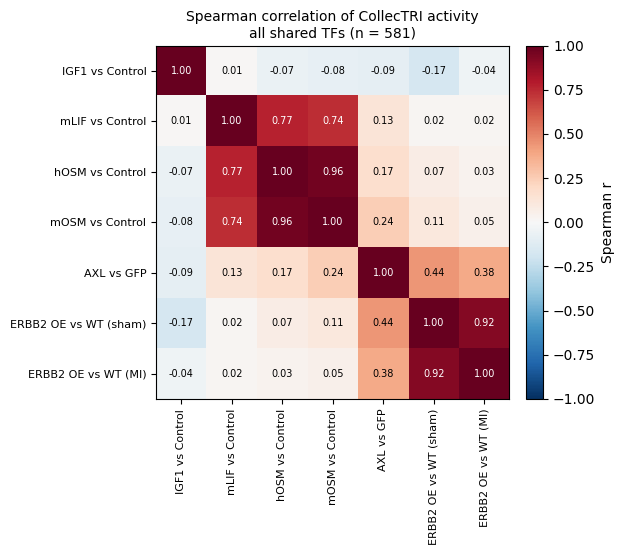

In [9]:
shared_tfs = activity_df.dropna().index
print(f'{len(shared_tfs)} TFs scored in every contrast')
tf_corr_all = activity_df.loc[shared_tfs].corr(method=corr_method)
tf_corr_all.to_csv(f'{results_dir}/collectri_correlation_{corr_method}_all_tfs.csv')
tf_contrast_order = clustered_order(tf_corr_all)   # same order for both heatmaps

plot_corr_heatmap(
    tf_corr_all,
    title=f'{corr_method.capitalize()} correlation of CollecTRI activity\nall shared TFs (n = {len(shared_tfs)})',
    fname=f'collectri_correlation_{corr_method}_all_tfs',
    order=tf_contrast_order,
)

### TFs significant in at least one contrast

151 shared TFs significant in at least one contrast


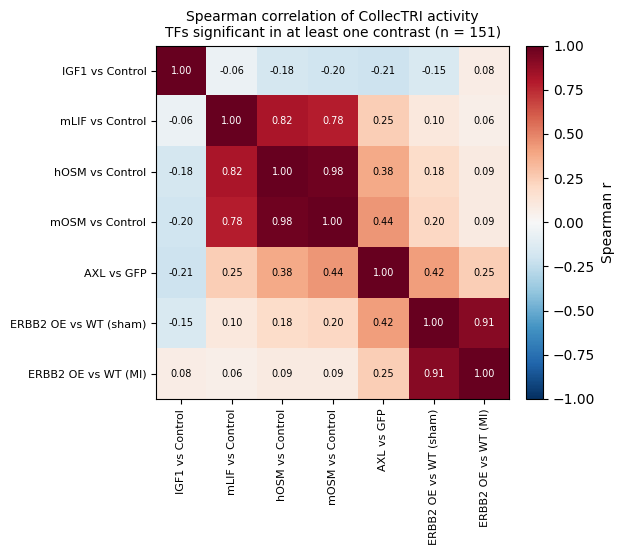

In [10]:
sig_any_shared_tfs = shared_tfs[sig_df.loc[shared_tfs].any(axis=1)]
print(f'{len(sig_any_shared_tfs)} shared TFs significant in at least one contrast')
tf_corr_sig = activity_df.loc[sig_any_shared_tfs].corr(method=corr_method)
tf_corr_sig.to_csv(f'{results_dir}/collectri_correlation_{corr_method}_sig_any_tfs.csv')

plot_corr_heatmap(
    tf_corr_sig,
    title=f'{corr_method.capitalize()} correlation of CollecTRI activity\nTFs significant in at least one contrast (n = {len(sig_any_shared_tfs)})',
    fname=f'collectri_correlation_{corr_method}_sig_any_tfs',
    order=tf_contrast_order,
)